### Required Libraries and Environment Setup

In [1]:
# Cell 1: Imports and Environment Setup

import numpy as np                
import pandas as pd  
import os    
import warnings 
import json
from datetime import datetime

# Efficient iteration helpers                  
import itertools                   
                 
# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
from matplotlib.lines import Line2D  
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns             
from IPython.display import display, HTML  

# Statistics
from scipy import stats           
from scipy.stats import (
    mannwhitneyu,                  
    ttest_ind,                     
    norm,                         
    probplot                      
)

# Bayesian analysis
import pymc as pm                
import arviz as az               
import pytensor             

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### Global Configuration: Paths, Analysis Parameters, and Plot Settings

In [2]:
# Cell 2: Global Configuration (Paths, Parameters, and Plot Style)

# Data paths and input settings
PATHS = {
    "P1": "NiS4-0.1V-1.npz",
    "P2": "NiS4-0.2V-1.npz",
    "P3": "NiS4-0.3V-1.npz",
    "P4": "NiS4-0.4V-1.npz",
    "P5": "NiS4-0.1V-2.npz",
}                               

# Statistical analysis settings
RANGE_CONFIG = {
    "P1": (-2, -1),
    "P2": (-1.85, -0.85),
    "P3": (-1.7, -0.7),
    "P4": (-1.5, -0.5),
    "P5": (-2, -1),
}

# Per-trace histogram bin width 
TRACE_HIST_BIN_WIDTH = 0.02           

# RNG seed
SEED = 42 
# Significance level
ALPHA = 0.05                         

# Sample sizes for sensitivity
M_VALUES_SENSITIVITY = [100, 200, 500, 1000] 

# Equivalence bound (ROPE / TOST)
DELTAS = {"delta": 0.05}
rng = np.random.default_rng(SEED)     

# Plot style
PLOT_CONFIG = {
    "FIG_WIDTH_SINGLE": 6,
    "FIG_HEIGHT_SINGLE": 5,
    "FONT_SIZE_LABEL": 16,
    "FONT_SIZE_TICK": 16,
    "FONT_SIZE_LEGEND": 14,
    "MARKER_SIZE": 10,
    "CAP_SIZE": 8,
    "SHOW_TITLE": False,
}

plt.rcParams.update({
    "font.size": PLOT_CONFIG["FONT_SIZE_TICK"],
    "axes.labelsize": PLOT_CONFIG["FONT_SIZE_LABEL"],
    "xtick.labelsize": PLOT_CONFIG["FONT_SIZE_TICK"],
    "ytick.labelsize": PLOT_CONFIG["FONT_SIZE_TICK"],
    "legend.fontsize": PLOT_CONFIG["FONT_SIZE_LEGEND"],
    "axes.titlesize": PLOT_CONFIG["FONT_SIZE_LABEL"],
    "lines.markersize": PLOT_CONFIG["MARKER_SIZE"],
    "figure.dpi": 120,
    "savefig.dpi": 330,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

### Feature Extraction Functions

In [3]:
# Cell 3: Feature Extraction Functions

def get_trace_modes_from_matrix(raw_traces, range_min, range_max, bin_width):
    """
    Extract per-trace mode (peak position) using a fixed-bin histogram.
    Steps: log10 transform (if needed) -> range gating -> histogram -> max-bin center mean.
    """
    extracted_modes = []
    bins = np.arange(range_min, range_max + bin_width, bin_width)

    for trace in raw_traces:
        log_t = np.asarray(trace, dtype=float)
        log_t = np.where(np.isfinite(log_t), log_t, np.nan)

        # Gate values within the analysis window
        valid_mask = np.isfinite(log_t) & (log_t >= range_min) & (log_t <= range_max)
        gated = log_t[valid_mask]

        # Require minimal support to avoid unstable peaks
        if gated.size < 5:
            continue
        counts, edges = np.histogram(gated, bins=bins)
        if counts.sum() == 0:
            continue

        # When max-count bins are not unique, use the mean of their centers
        max_count = counts.max()
        max_idx = np.flatnonzero(counts == max_count)
        centers = (edges[max_idx] + edges[max_idx + 1]) / 2.0
        extracted_modes.append(centers.mean())

    return np.asarray(extracted_modes, dtype=float)


### Hypothesis Testing Functions

In [4]:
# Cell 4: Hypothesis Testing Functions

# Parametric tests (Welch t-test and TOST)

def calculate_welch_dof(a, b):
    """Compute Welch-Satterthwaite degrees of freedom."""
    n1, n2 = len(a), len(b)
    v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)

    if v1 == 0 and v2 == 0:
        return n1 + n2 - 2

    numerator = (v1 / n1 + v2 / n2) ** 2
    denominator = (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)

    if denominator == 0:
        return n1 + n2 - 2
    return numerator / denominator


def welch_t_test(a, b):
    """Run Welch's t-test (unequal variances). Returns (t, p)."""
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    return stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")


def calculate_welch_ci(a, b, conf_level=0.95):
    """CI for mean difference (Welch). Returns mean_diff, (low, high)."""
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, (np.nan, np.nan)

    mean_diff = np.mean(a) - np.mean(b)
    std_err = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))

    if std_err == 0:
        return mean_diff, (mean_diff, mean_diff)

    dof = calculate_welch_dof(a, b)
    alpha_ci = 1 - conf_level
    t_crit = stats.t.ppf(1 - alpha_ci / 2, df=dof)

    ci_low = mean_diff - t_crit * std_err
    ci_high = mean_diff + t_crit * std_err
    return mean_diff, (ci_low, ci_high)


def tost_welch(a, b, delta, alpha):
    """
    TOST equivalence test with Welch SE.
    Returns equivalent (bool), (ci_low, ci_high) for (1-2*alpha) CI.
    """
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return False, (np.nan, np.nan)

    dof = calculate_welch_dof(a, b)
    mean_diff = np.mean(a) - np.mean(b)
    std_err = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))

    if std_err == 0:
        return (-delta < mean_diff < delta), (mean_diff, mean_diff)

    # One-sided tests against +/- delta
    t_lower = (mean_diff + delta) / std_err
    t_upper = (mean_diff - delta) / std_err
    p_lower = stats.t.sf(t_lower, df=dof)
    p_upper = stats.t.cdf(t_upper, df=dof)

    equivalent = (p_lower < alpha) and (p_upper < alpha)

    # (1-2*alpha) CI used by TOST (e.g., 90% when alpha=0.05)
    t_crit = stats.t.ppf(1 - alpha, df=dof)
    ci_low = mean_diff - t_crit * std_err
    ci_high = mean_diff + t_crit * std_err

    return equivalent, (ci_low, ci_high)


### Bayesian Inference Functions (PyMC Student-T Model)

In [5]:
# Cell 5: Bayesian Inference (PyMC, Student-T)

def get_bayesian_posterior(data_dict: dict, random_seed: int):
    """Fit a two-group Student-T model and return posterior samples."""
    labels = list(data_dict.keys())
    if len(labels) < 2:
        return None, None

    group_A, group_B = labels[0], labels[1]

    # Clean inputs (float64, finite only)
    y_a = np.asarray(data_dict[group_A], dtype="float64")
    y_a = y_a[np.isfinite(y_a)]
    y_b = np.asarray(data_dict[group_B], dtype="float64")
    y_b = y_b[np.isfinite(y_b)]

    # Minimal sample size for stable inference
    if len(y_a) < 5 or len(y_b) < 5:
        return None, None

    # Pooled stats for weakly-informative priors
    pooled_data = np.concatenate([y_a, y_b])
    if pooled_data.size > 1:
        pooled_mean = np.mean(pooled_data)
        pooled_std = np.std(pooled_data)
    else:
        pooled_mean, pooled_std = 0.0, 1.0

    pooled_std = max(pooled_std, 1e-4)  # Avoid degenerate scales

    with pm.Model() as model:
        # Priors for group means and scales
        prior_mu_mean = pooled_mean
        prior_mu_sigma = pooled_std * 5
        prior_sigma_sigma = pooled_std * 5

        mu_a = pm.Normal(f"mu_{group_A}", mu=prior_mu_mean, sigma=prior_mu_sigma)
        sigma_a = pm.HalfNormal(f"sigma_{group_A}", sigma=prior_sigma_sigma)

        mu_b = pm.Normal(f"mu_{group_B}", mu=prior_mu_mean, sigma=prior_mu_sigma)
        sigma_b = pm.HalfNormal(f"sigma_{group_B}", sigma=prior_sigma_sigma)

        # Student-T df (nu) for outlier-robust likelihood
        nu = pm.Exponential("nu_minus_one", 1 / 29.0) + 1.0

        pm.StudentT(f"obs_{group_A}", nu=nu, mu=mu_a, sigma=sigma_a, observed=y_a)
        pm.StudentT(f"obs_{group_B}", nu=nu, mu=mu_b, sigma=sigma_b, observed=y_b)

        # Posterior target: mean difference
        pm.Deterministic("difference_of_means", mu_a - mu_b)

        try:
            trace = pm.sample(
                draws=2000,
                tune=1000,
                chains=2,
                random_seed=random_seed,
                progressbar=False,
                init="adapt_diag",
                target_accept=0.95,
                cores=1,
            )
        except Exception as e:
            print(f"Bayesian sampling failed internal: {e}")
            return None, None

    # priors_dict = {
    #     "diff_mean": 0.0,
    #     "diff_sigma": np.sqrt(prior_mu_sigma**2 + prior_mu_sigma**2),
    # }
    priors_dict = None
    return trace, priors_dict

### Data Loading and Preprocessing (NPZ Files)

In [6]:
# Cell 6: Data Loading (NPZ)

groups_data_raw = {}      # Raw trace matrices: (n_traces, n_points)
groups_data_full_1d = {}  # Flattened finite values (for 1D hist)

for name, path in PATHS.items():
    # Load NPZ file 
    with np.load(path, allow_pickle=True) as data:
        arr = data["conductance_array"] 

    groups_data_raw[name] = arr

    # Flatten finite values for visualization
    flat = np.asarray(arr, dtype=float).ravel()
    groups_data_full_1d[name] = flat[np.isfinite(flat)]
    print(f"  - {name}: Loaded {arr.shape[0]} traces (valid points: {len(groups_data_full_1d[name])})")

  - P1: Loaded 1065 traces (valid points: 1491000)
  - P2: Loaded 1233 traces (valid points: 1849500)
  - P3: Loaded 1181 traces (valid points: 1771500)
  - P4: Loaded 1247 traces (valid points: 1496400)
  - P5: Loaded 1058 traces (valid points: 1481200)


### Feature Extraction and Descriptive Statistics

In [7]:
# Cell 7: Feature Extraction

trace_features_all = {}  # Per-group mode values (one value per valid trace)
stats_summary = []
 
for name, raw_data in groups_data_raw.items():
    # Analysis window for this group
    min_r, max_r = RANGE_CONFIG[name] 
    
    # Use all traces in the group
    total_traces = raw_data.shape[0]
    data_to_process = raw_data
    print(f"  - {name}: Using all {total_traces} traces...")

    # Extract per-trace modes using fixed binning
    modes = get_trace_modes_from_matrix(
        data_to_process, min_r, max_r, TRACE_HIST_BIN_WIDTH,
    )

    # Store results and basic distribution stats
    trace_features_all[name] = modes

    stats_summary.append({
        "Group": name, "N (Samples)": len(modes),
        "Mean": np.mean(modes), "Median": np.median(modes),
        "Std Dev": np.std(modes), "Skewness": stats.skew(modes),
    })


# Display summary table
if stats_summary:
    df_stats = pd.DataFrame(stats_summary)
    display(
        df_stats.style.format({
            "Mean": "{:.4f}", "Median": "{:.4f}", "Std Dev": "{:.4f}", "Skewness": "{:.3f}",
        }).hide(axis="index")
    )

  - P1: Using all 1065 traces...
  - P2: Using all 1233 traces...
  - P3: Using all 1181 traces...
  - P4: Using all 1247 traces...
  - P5: Using all 1058 traces...


Group,N (Samples),Mean,Median,Std Dev,Skewness
P1,1065,-1.4843,-1.4800,0.2950,-0.069
P2,1233,-1.3370,-1.3300,0.2967,-0.041
P3,1181,-1.1983,-1.1700,0.2843,-0.110
P4,1247,-1.0031,-1.0100,0.2835,0.006
P5,1058,-1.5023,-1.5100,0.2935,0.038


### Posterior Density Panel Plotting Function

In [10]:
# Cell 8a: Posterior panel plotter (single axis)

def plot_posterior_panel(
    ax, posterior_data, rope_interval, m_val, group_A_label, group_B_label, forced_xlim,
):
    """
    Plot posterior density with:
      - ROPE and boundaries
      - P(Δ>0) and % in ROPE
      - HDI (95% + 50%) and median marker
      - Directional "Favors" arrows
    """

    # Density on a fixed x-grid (shared xlim across panels)
    density = stats.gaussian_kde(posterior_data, bw_method=0.3)
    x_grid = np.linspace(forced_xlim[0], forced_xlim[1], 1000)
    y_grid = density(x_grid)
    ymax = np.max(y_grid)

    # Style color
    color_dark_blue = '#4a90e2'
    color_text_prob = '#1f78b4'  
    color_text_rope = '#555555'  
    col_bd = '#7f7f7f'
    dash = (0, (6, 4))

    # ROPE region (background)
    ax.axvspan(rope_interval[0], rope_interval[1], color='#d9d9d9', alpha=0.2, zorder=0)

    # Density curve + fill by sign
    ax.plot(x_grid, y_grid, color='#1d3f72', lw=1.5, alpha=0.85, zorder=3)
    ax.fill_between(x_grid, 0, y_grid, where=(x_grid < 0), color=color_dark_blue, alpha=0.85, zorder=2)
    ax.fill_between(x_grid, 0, y_grid, where=(x_grid >= 0), color=color_dark_blue, alpha=0.85, zorder=2)

    # Reference line at 0
    ax.axvline(0.0, linestyle=dash, color='#333333', lw=1.5, alpha=0.6, zorder=4)

    # Probabilities (top corner, auto-left/right)
    prob_gt_0 = float(np.mean(posterior_data > 0))
    prob_in_rope = float(np.mean((posterior_data >= rope_interval[0]) & (posterior_data <= rope_interval[1])))

    center_mass = float(np.mean(posterior_data))
    mid_point = 0.5 * (forced_xlim[0] + forced_xlim[1])
    text_x, text_ha = (0.04, "left") if center_mass > mid_point else (0.96, "right")

    ax.text(
        0.4, 0.85, f"P($\\Delta$ > 0) = {prob_gt_0:.0%}", transform=ax.transAxes, color=color_text_prob,
        fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"], ha=text_ha, fontweight="bold", zorder=20,
    )
    ax.text(
        0.4, 0.72, f"% in ROPE = {prob_in_rope:.1%}", transform=ax.transAxes, color=color_text_rope,
        fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"], ha=text_ha, zorder=20,
    )

    # HDIs + median 
    median = np.median(posterior_data)
    hdi_95 = az.hdi(posterior_data, hdi_prob=0.95)

    y_offset = -0.05 * ymax

    # 95% HDI line + median dot
    ax.plot([hdi_95[0], hdi_95[1]], [y_offset, y_offset], color='black', lw=2.5, zorder=10)
    ax.plot(median, y_offset, 'o', color='black', ms=9, zorder=12)

    # ROPE boundaries
    ax.axvline(-delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=4)
    ax.axvline( delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=4)
    
    # ±delta labels
    trans = ax.get_xaxis_transform()
    ax.text(-delta_val, 0.5, r"$-\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")
    ax.text(delta_val, 0.5, r"$+\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")
    
    # “Favors” arrows
    # arrow_y = 1.05
    # ax.annotate(
    #     f"Favors {group_A_label}",
    #     xy=(0.02, arrow_y),
    #     xycoords="axes fraction",
    #     xytext=(0.45, arrow_y),
    #     textcoords="axes fraction",
    #     arrowprops=dict(arrowstyle="->", color="black", lw=2.5),
    #     ha="right",
    #     va="center",
    #     fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"],
    #     fontweight="bold",
    #     color="black",
    # )
    # ax.annotate(
    #     f"Favors {group_B_label}",
    #     xy=(0.98, arrow_y),
    #     xycoords="axes fraction",
    #     xytext=(0.55, arrow_y),
    #     textcoords="axes fraction",
    #     arrowprops=dict(arrowstyle="->", color="black", lw=2.5),
    #     ha="left",
    #     va="center",
    #     fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"],
    #     fontweight="bold",
    #     color="black",
    # )

    # Axes formatting
    ax.set_xlim(forced_xlim)
    ax.set_facecolor('white')
    ax.set_ylim(bottom=y_offset * 2.0, top=ymax * 1.5)

    ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax.set_ylabel("Posterior Density", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])


    ax.tick_params(axis='x', which='major', width=1.5, length=5, bottom=True, top=False)     
    ax.tick_params(axis='y', which='major', width=1.5, length=5, left=True, right=False)     
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    for side in ['bottom', 'left', 'top', 'right']:
        ax.spines[side].set_zorder(1000)

### Bayesian Overlay Posterior Analysis Across Multiple Group Comparisons

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Bayesian Summary Table: P1 vs P2


M (Traces),Mean Diff,95% HDI Low,95% HDI High,% in ROPE,P(P1 > P2)
Full (1065 vs 1233),-0.1470,-0.1716,-0.1238,0.0%,0.0%


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P3, sigma_P3, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Bayesian Summary Table: P1 vs P3


...

Bayesian Summary Table: P3 vs P5


M (Traces),Mean Diff,95% HDI Low,95% HDI High,% in ROPE,P(P3 > P5)
Full (1181 vs 1058),0.3041,0.2805,0.3284,0.0%,100.0%


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P4, sigma_P4, mu_P5, sigma_P5, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Bayesian Summary Table: P4 vs P5


M (Traces),Mean Diff,95% HDI Low,95% HDI High,% in ROPE,P(P4 > P5)
Full (1247 vs 1058),0.4993,0.4756,0.5241,0.0%,100.0%


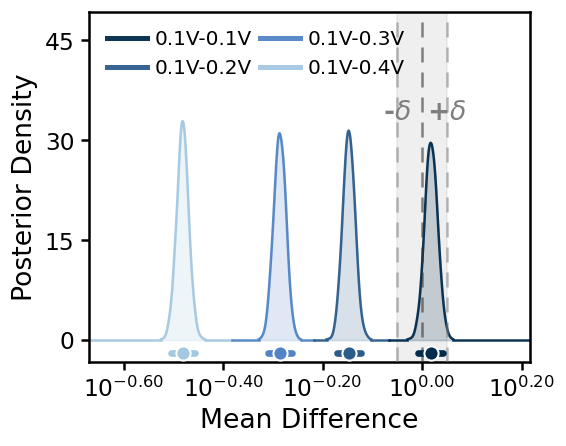

In [20]:
# Cell 8b: Bayesian Overlay Posterior Analysis Across Multiple Group Comparisons
# Ensure Arviz/PyTensor cache is clear
try:
    pytensor.clear_cache()
except:
    pass

# Equivalence bound (Delta) -> ROPE
delta_val = DELTAS["delta"]
rope = (-delta_val, delta_val)

group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))

# Overlay config
BASE_GROUP = "P1"
OVERLAY_TARGETS = {"P5", "P2", "P3", "P4"}
overlay_meandiff = {}   # key: P2/P3/P4, val: mean difference
overlay_posts = {}      # key: P2/P3/P4, val: posterior samples

for pair in all_pairs:
    group_A, group_B = pair

    # Explicit range selection
    min_A, max_A = RANGE_CONFIG[group_A] if group_A in RANGE_CONFIG else RANGE_CONFIG["DEFAULT"]
    min_B, max_B = RANGE_CONFIG[group_B] if group_B in RANGE_CONFIG else RANGE_CONFIG["DEFAULT"]

    raw_A = groups_data_raw[group_A]
    raw_B = groups_data_raw[group_B]

    # Full-data sampling
    sample_A = raw_A
    sample_B = raw_B

    label_n = f"Full ({len(raw_A)} vs {len(raw_B)})"

    # Extract per-trace histogram modes
    vals_A = get_trace_modes_from_matrix(sample_A, min_A, max_A, TRACE_HIST_BIN_WIDTH)
    vals_B = get_trace_modes_from_matrix(sample_B, min_B, max_B, TRACE_HIST_BIN_WIDTH)

    if len(vals_A) < 5 or len(vals_B) < 5:
        print(f"[Skip] {group_A} vs {group_B}: not enough valid modes (A={len(vals_A)}, B={len(vals_B)})")
        continue

    # 2) Bayesian inference (single run per pair)
    data_for_pair = {group_A: vals_A, group_B: vals_B}
    trace, priors = get_bayesian_posterior(data_for_pair, SEED)

    post_samples = trace.posterior['difference_of_means'].values.flatten()

    # Collect overlay data (P1 vs P2/P3/P4)
    if group_A == BASE_GROUP and group_B in OVERLAY_TARGETS:
        overlay_posts[group_B] = post_samples
        overlay_meandiff[group_B] = float(np.mean(post_samples))
    elif group_B == BASE_GROUP and group_A in OVERLAY_TARGETS:
        overlay_posts[group_A] = -post_samples
        overlay_meandiff[group_A] = float(np.mean(-post_samples))

    # Summary stats
    hdi_val = az.hdi(post_samples, hdi_prob=0.95)
    in_rope = float(np.mean((post_samples >= rope[0]) & (post_samples <= rope[1])))
    p_gt = float(np.mean(post_samples > 0))

    # Result table for this pair 
    summary_table_rows = [{
        "M (Traces)": label_n,
        "Mean Diff": float(np.mean(post_samples)),
        "95% HDI Low": float(hdi_val[0]),
        "95% HDI High": float(hdi_val[1]),
        "% in ROPE": in_rope,
        f"P({group_A} > {group_B})": p_gt
    }]

    print(f"Bayesian Summary Table: {group_A} vs {group_B}")
    df_bayes = pd.DataFrame(summary_table_rows)

    prob_col = f"P({group_A} > {group_B})"
    cols_to_show = ["M (Traces)", "Mean Diff", "95% HDI Low", "95% HDI High", "% in ROPE", prob_col]

    format_dict = {
        "Mean Diff": "{:.4f}",
        "95% HDI Low": "{:.4f}", "95% HDI High": "{:.4f}",
        "% in ROPE": "{:.1%}", prob_col: "{:.1%}"
    }

    display(df_bayes[cols_to_show].style.format(format_dict).hide(axis="index"))

# Overlay Posterior Mountain Plot: (P1 vs P2/P3/P4) in ONE figure
if overlay_posts:
    fig, ax = plt.subplots(figsize=(5, 4))  # keep your single-figure style
    LW = 1.5

    # Unified xlim: cover 95% HDIs + ROPE bounds
    all_hdi = [az.hdi(p, hdi_prob=0.95) for p in overlay_posts.values()]
    x_low  = float(min([h[0] for h in all_hdi] + [rope[0]]))
    x_high = float(max([h[1] for h in all_hdi] + [rope[1]]))

    span = max(1e-9, x_high - x_low)
    pad  = 0.3 * span
    final_xlim = (x_low - pad, x_high + pad)

    # KDE evaluation grid
    x_grid = np.linspace(final_xlim[0], final_xlim[1], 1000)

    # Background ROPE band + reference lines
    col_bd  = '#7f7f7f'
    dash = (0, (6, 4))

    ax.axvspan(-delta_val, delta_val, color=col_bd, alpha=0.12, zorder=0)
    ax.axvline(0.0, linestyle=dash, color='#333333', lw=LW, alpha=0.6, zorder=4)
    ax.axvline(-delta_val, linestyle=dash, color=col_bd, lw=LW, alpha=0.55, zorder=4)
    ax.axvline( delta_val, linestyle=dash, color=col_bd, lw=LW, alpha=0.55, zorder=4)
    
    label_y_offset = 0.75
    ax.text(rope[0], label_y_offset, r"-$\delta$", ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"], color=col_bd, fontweight='bold')
    ax.text(rope[1], label_y_offset, r"+$\delta$", ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"], color=col_bd, fontweight='bold')
    
    ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax.set_ylabel("Posterior Density", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])

    # Blue shades: closer to 0 -> lighter (as in your original logic)
    blue_light = "#002B4D"
    blue_lightmid = "#2c5c8a"
    blue_mid   = "#5184c4"
    blue_dark  = "#A4C8E1"
    shade_list = [blue_light, blue_lightmid, blue_mid, blue_dark]

    available = [k for k in ["P5", "P2", "P3", "P4"] if k in overlay_posts]
    order_by_close_to_zero = sorted(available, key=lambda k: abs(np.mean(overlay_posts[k])))

    color_map = {}
    for i, k in enumerate(order_by_close_to_zero):
        color_map[k] = shade_list[min(i, len(shade_list)-1)]

    intervals = []      
    ymax_all = 0.0     
    hdi_infos = []      # median + 95% HDI (for bottom markers)
    peak_infos = []     # peak (x,y) + mean-diff text (for annotations)
    voltage_map = {"P5": "0.1V", "P1": "0.1V", "P2": "0.2V", "P3": "0.3V", "P4": "0.4V"}

    for other in ["P5", "P2", "P3", "P4"]:
        if other not in overlay_posts:
            continue

        post = overlay_posts[other]
        kde = stats.gaussian_kde(post, bw_method=0.3)
        y = kde(x_grid)
        ymax_all = max(ymax_all, float(np.max(y)))

        eps = 0.003 * float(np.max(y))
        mask = y > eps

        c = color_map.get(other, blue_mid)

        idx = np.where(mask)[0]
        if idx.size > 0:
            x_start = float(x_grid[idx[0]])
            x_end   = float(x_grid[idx[-1]])
            intervals.append({"other": other, "start": x_start, "end": x_end, "color": c})
            
        # Legend label: show voltage difference (P1-P2 / P1-P3 / P1-P4)
        label_str = f"{voltage_map.get(BASE_GROUP, BASE_GROUP)}-{voltage_map.get(other, other)}"

        med = float(np.median(post))
        hdi = az.hdi(post, hdi_prob=0.95)
        hdi_infos.append({
            "other": other,
            "median": med,
            "hdi_low": float(hdi[0]),
            "hdi_high": float(hdi[1]),
            "color": c
        })

        ax.plot(x_grid[mask], y[mask], lw=LW, color=c, alpha=0.95, label=label_str)
        ax.fill_between(x_grid, 0, y, where=mask, color=c, alpha=0.18, interpolate=True)
        mean_diff = float(overlay_meandiff.get(other, np.mean(post)))

        i_peak = int(np.argmax(y))
        x_peak = float(x_grid[i_peak])
        y_peak = float(y[i_peak])

        peak_infos.append({
            "other": other, "x": x_peak, "y": y_peak, "color": c, "text": f"{mean_diff:.3f}",
        })
    # if len(peak_infos) >= 1:
    #     peak_infos = sorted(peak_infos, key=lambda d: d["x"]) 
    #     x_span = max(1e-9, final_xlim[1] - final_xlim[0])
    #     dx = 0.025 * x_span
    #     dy = -0.5 * ymax_all
    #     y_cap = 0.90 * (ymax_all * 1.5)
    #     y_fixed = min([d["y"] for d in peak_infos]) + dy
    #     y_fixed = min(y_fixed, y_cap)  
    #     for i, info in enumerate(peak_infos):
    #         if i >= len(peak_infos) - 2:
    #             x_txt = info["x"] + dx
    #             ha = "left"
    #         else:
    #             x_txt = info["x"] - dx
    #             ha = "right"
    #         ax.text(
    #             x_txt, y_fixed, info["text"], ha=ha, va="bottom", fontsize=12, color=info["color"], zorder=6
    #         )

    # Draw median dots + 95% HDI segments (same y level)
    if len(hdi_infos) > 0:
        y_hdi = -0.06 * ymax_all  # keep your logic
        for s in hdi_infos:
            lo, hi, med, c = s["hdi_low"], s["hdi_high"], s["median"], s["color"]
            ax.plot([lo, hi], [y_hdi, y_hdi], color=c, lw=4, solid_capstyle='round', zorder=7)
            ax.plot(med, y_hdi, 'o', color=c, ms=8.5, markeredgecolor='white', markeredgewidth=1.2, zorder=8)

    # Patch y=0 baselines between intervals (your original logic)
    if intervals:
        intervals = sorted(intervals, key=lambda d: d["start"])
        xL, xR = float(final_xlim[0]), float(final_xlim[1])

        def _draw_base(seg_l, seg_r, color):
            if seg_r > seg_l:
                ax.plot([seg_l, seg_r], [0.0, 0.0], color=color, lw=LW, alpha=0.95, zorder=2)

        _draw_base(xL, intervals[0]["start"], intervals[0]["color"])

        for i in range(len(intervals) - 1):
            left  = intervals[i]
            right = intervals[i + 1]
            gap_l = left["end"]
            gap_r = right["start"]
            if gap_r <= gap_l:
                continue
            mid = 0.5 * (gap_l + gap_r)
            _draw_base(gap_l, mid, left["color"])
            _draw_base(mid, gap_r, right["color"])

        _draw_base(intervals[-1]["end"], xR, intervals[-1]["color"])

    # Axis formatting (keep your original style)
    ax.set_xlim(final_xlim)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    # ax.tick_params(axis='x', which='major', width=LW, length=5, labelbottom=False, labelleft=False)
    # ax.tick_params(axis='y', which='major', width=LW, length=5, labelbottom=False, labelleft=False)
    ax.tick_params(axis='x', which='major', width=LW, length=5)
    ax.tick_params(axis='y', which='major', width=LW, length=5)
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: rf"$10^{{{x:.2f}}}$")
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    y_offset = -0.05 * ymax_all
    ax.set_ylim(bottom=y_offset * 2.0, top=ymax_all * 1.5)
    leg = ax.legend(
        loc='upper left', 
        frameon=False,
        fontsize=12,
        ncol=2,
        handlelength=2.0,
        columnspacing=0.4,
        handletextpad=0.4
    )

    for h in leg.legend_handles:
        h.set_linewidth(3.0)  
    
    plt.tight_layout()
    plt.savefig("Bayesian_Analysis_NiS4-0.1V~0.4V.png", bbox_inches='tight')
    plt.show()

### Forest-Style HDI Summary for Multiple Pairwise Bayesian Comparisons

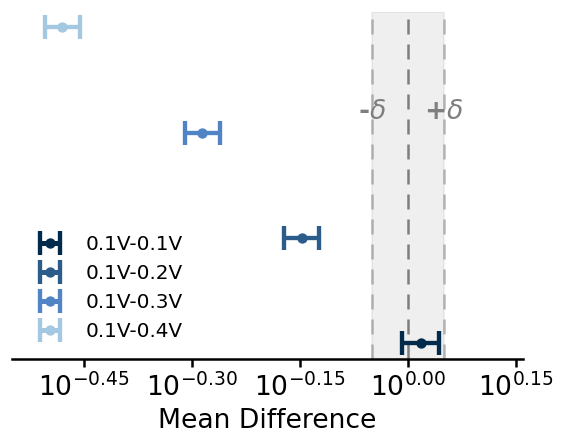

In [21]:
# Cell 8c: Forest-style HDI Summary (P1 vs P2/P3/P4)

assert "overlay_posts" in globals() and len(overlay_posts) > 0, \
    "overlay_posts is empty: run the overlay part in Cell 11b first."

BASE_GROUP = "P1"
order = ["P5", "P2", "P3", "P4"]
voltage_map = {"P1": "0.1V", "P5": "0.1V", "P2": "0.2V", "P3": "0.3V", "P4": "0.4V"}
available = [k for k in order if k in overlay_posts]

# Colors: three blue shades
blue_light = "#002B4D"
blue_lightmid = "#2c5c8a"
blue_mid   = "#5184c4"
blue_dark  = "#A4C8E1"
shade_list = [blue_light, blue_lightmid, blue_mid, blue_dark]
order_by_close_to_zero = sorted(
    available, key=lambda k: abs(np.mean(np.asarray(overlay_posts[k]).ravel()))
)
color_map_local = {k: shade_list[min(i, len(shade_list)-1)] for i, k in enumerate(order_by_close_to_zero)}

fig, ax = plt.subplots(figsize=(5, 4))

# Background: ROPE band + reference lines (0 and ±δ)
col_bd = '#7f7f7f'
LW = 1.5
dash = (0, (6, 4))

ax.axvspan(-delta_val, delta_val, color=col_bd, alpha=0.12, zorder=0)
ax.axvline(0.0,        linestyle=dash, color='#333333', lw=LW, alpha=0.6,  zorder=1)
ax.axvline(-delta_val, linestyle=dash, color=col_bd,    lw=LW, alpha=0.55, zorder=1)
ax.axvline( delta_val, linestyle=dash, color=col_bd,    lw=LW, alpha=0.55, zorder=1)

# Y positions
ypos = {k: i for i, k in enumerate(available)}

# X limits: cover all HDIs + ROPE with a small padding
hdi_prob = 0.95
hdis = []
for k in available:
    post = np.asarray(overlay_posts[k]).ravel()
    lo, hi = az.hdi(post, hdi_prob=hdi_prob)
    hdis.append((float(lo), float(hi)))

x_low  = min([lo for lo, _ in hdis] + [rope[0]])
x_high = max([hi for _, hi in hdis] + [rope[1]])
span = max(1e-9, x_high - x_low)
pad  = 0.05 * span
ax.set_xlim(x_low - pad, x_high + pad)

# Plot: HDI segment + mean dot (one row per comparison)
for k in available:
    post = np.asarray(overlay_posts[k]).ravel()
    mu  = float(np.mean(post))
    lo, hi = az.hdi(post, hdi_prob=hdi_prob)
    lo, hi = float(lo), float(hi)

    y = ypos[k]
    c = color_map_local.get(k, blue_mid)

    ax.errorbar(
        x=mu, y=y,
        xerr=[[mu - lo], [hi - mu]],
        fmt="o",
        color=c, ecolor=c,
        elinewidth=2.6, capsize=7, capthick=2.6,
        markersize=5.2,
        zorder=3,
        label=f"{voltage_map.get(BASE_GROUP, BASE_GROUP)}-{voltage_map.get(k, k)}"
    )

# Styling: no axis labels, hide y ticks, keep x ticks
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.tick_params(axis='x', which='major', width=LW, length=5) # update
ax.tick_params(axis='y', which='major', width=LW, length=5)
# ax.tick_params(axis='x', which='major', width=LW, length=5, labelbottom=False, labelleft=False) # update
# ax.tick_params(axis='y', which='major', width=LW, length=5, labelbottom=False, labelleft=False)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: rf"$10^{{{x:.2f}}}$")
)
# Optional: manually override x-range (example)
ax.set_xlim(-0.55, 0.16)

label_y_offset = 0.75
ax.text(rope[0], label_y_offset, r"-$\delta$", ha='center', va='top',
        transform=ax.get_xaxis_transform(), fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"], color=col_bd, fontweight='bold')
ax.text(rope[1], label_y_offset, r"+$\delta$", ha='center', va='top',
        transform=ax.get_xaxis_transform(), fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"], color=col_bd, fontweight='bold')
    
ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])

# Spines: keep bottom only
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(LW)
for side in ["left", "right", "top"]:
    ax.spines[side].set_visible(False)
    
leg = ax.legend(
    loc='lower left', 
    frameon=False,
    fontsize=12,
    ncol=1,
    handlelength=2.0
)
# Make legend line handles thicker
for h in leg.legend_handles:
    h.set_linewidth(3.0)  
    
plt.tight_layout()
plt.savefig("HDI_Analysis_NiS4-0.1V~0.4V.png", bbox_inches="tight")
plt.show()
